# Рубежный контроль №1 (весна 2025 года)
**Студент:** Утенков Алексей Павлович

**Группа:** ИУ5-61Б

|Номер задания|Номер задачи|Номер набора данных, указанного в задаче|
|:---:|:---:|:---:|
|14|2|6|

**Дополнительные требования:**
Для пары произвольных колонок данных построить график "Диаграмма рассеяния".

**Задача №2**  
Для заданного набора данных проведите обработку пропусков в данных для одного категориального и одного количественного признака. Какие способы обработки пропусков в данных для категориальных и количественных признаков Вы использовали? Какие признаки Вы будете использовать для дальнейшего построения моделей машинного обучения и почему?

**Датасет**
https://www.kaggle.com/datasets/mohansacharya/graduate-admissions?select=Admission_Predict_Ver1.1.csv

## Импорт библиотек

In [56]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import *
from sklearn.impute import SimpleImputer, MissingIndicator
from sklearn.preprocessing import LabelEncoder
%matplotlib inline 
sns.set(style="ticks")

## Загрузка данных

In [57]:
data = pd.read_csv('data/Admission_Predict_Ver1.1.csv', sep=",")

## Основные характеристики датасета

In [58]:
# Первые 5 строк датасета
data.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [59]:
# Размер датасета - 1025 строк, 14 колонок
data.shape

(500, 9)

In [60]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [61]:
total_count = data.shape[0]

In [62]:
data.isnull().sum() # в датасете отсутствуют пропуски 

Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

In [63]:
# Добавим искусственные пропуски для демонстрации
np.random.seed(42)
mask_quantitative = np.random.choice([True, False], size=len(data), p=[0.1, 0.9])
mask_categorical = np.random.choice([True, False], size=len(data), p=[0.1, 0.9])

In [64]:
# Создаем пропуски в количественном признаке (sepal length)
data.loc[mask_quantitative, 'GRE Score'] = np.nan

# Создаем искусственный категориальный признак и добавляем в него пропуски
data['flower_color'] = np.random.choice(['red', 'blue', 'yellow'], size=len(data))
data.loc[mask_categorical, 'flower_color'] = np.nan

In [65]:
print("Данные с пропусками:")
print(data.isnull().sum())

Данные с пропусками:
Serial No.            0
GRE Score            65
TOEFL Score           0
University Rating     0
SOP                   0
LOR                   0
CGPA                  0
Research              0
Chance of Admit       0
flower_color         43
dtype: int64


In [66]:
# Определим уникальные значения для категориальных признаков
data['flower_color'].unique()

array(['yellow', 'blue', 'red', nan], dtype=object)

In [67]:
data['Chance of Admit '].unique()

array([0.92, 0.76, 0.72, 0.8 , 0.65, 0.9 , 0.75, 0.68, 0.5 , 0.45, 0.52,
       0.84, 0.78, 0.62, 0.61, 0.54, 0.66, 0.63, 0.64, 0.7 , 0.94, 0.95,
       0.97, 0.44, 0.46, 0.74, 0.91, 0.88, 0.58, 0.48, 0.49, 0.53, 0.87,
       0.86, 0.89, 0.82, 0.56, 0.36, 0.42, 0.47, 0.55, 0.57, 0.96, 0.93,
       0.38, 0.34, 0.79, 0.71, 0.69, 0.59, 0.85, 0.77, 0.81, 0.83, 0.67,
       0.73, 0.6 , 0.43, 0.51, 0.39, 0.37])

Целевой признак является бинарным; содержит значения 0-1.

## Обработка пустых значений

Категориальный признак

In [68]:
temp_null_count = data[data['flower_color'].isnull()].shape[0]
dt = str(data['flower_color'].dtype)
temp_perc = round((temp_null_count / total_count) * 100.0, 2)
print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format('flower_color', dt, temp_null_count, temp_perc))

Колонка flower_color. Тип данных object. Количество пустых значений 43, 8.6%.


In [69]:
# Обработка пропусков в категориальном признаке (мода)
mode_rating = data['flower_color'].mode()[0]
print(f"Мода для flower_color: {mode_rating}")
data['flower_color'] = data['flower_color'].fillna(mode_rating)

data[['flower_color']]

Мода для flower_color: red


,flower_color
0,yellow
1,blue
2,yellow
3,yellow
4,red
...,...
495,red
496,yellow
497,yellow
498,blue


Количественный признак

In [70]:
temp_null_count = data[data['GRE Score'].isnull()].shape[0]
dt = str(data['GRE Score'].dtype)
temp_perc = round((temp_null_count / total_count) * 100.0, 2)
print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format('GRE Score', dt, temp_null_count, temp_perc))

Колонка GRE Score. Тип данных float64. Количество пустых значений 65, 13.0%.


In [71]:
# Обработка пропусков в количественном признаке (медиана)
quantitative_imputer = SimpleImputer(strategy='median')
data['GRE Score'] = quantitative_imputer.fit_transform(
    data[['GRE Score']])

data[['GRE Score']]

,GRE Score
0,337.0
1,324.0
2,316.0
3,322.0
4,314.0
...,...
495,332.0
496,337.0
497,317.0
498,312.0


Повторная проверка пустых значений

In [72]:
print("\nДанные после обработки пропусков:")
print(data.isnull().sum())


Данные после обработки пропусков:
Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
flower_color         0
dtype: int64


## Подготовка к использованию в модели

In [ ]:
# Признаки для построения моделей
features = ['GRE Score', 'TOEFL Score', 
            'University Rating', 'SOP'
            ]
chance_class = 'Chance of Admit '

In [74]:
data[features].describe()

,GRE Score,TOEFL Score,University Rating,SOP
count,500.000000,500.000000,500.000000,500.000000
mean,316.692000,107.192000,3.114000,3.374000
std,10.395059,6.081868,1.143512,0.991004
min,290.000000,92.000000,1.000000,1.000000
25%,310.750000,103.000000,2.000000,2.500000
50%,317.000000,107.000000,3.000000,3.500000
75%,324.000000,112.000000,4.000000,4.000000
max,340.000000,120.000000,5.000000,5.000000


In [ ]:
data[chance_class].unique()

array([0.92, 0.76, 0.72, 0.8 , 0.65, 0.9 , 0.75, 0.68, 0.5 , 0.45, 0.52,
       0.84, 0.78, 0.62, 0.61, 0.54, 0.66, 0.63, 0.64, 0.7 , 0.94, 0.95,
       0.97, 0.44, 0.46, 0.74, 0.91, 0.88, 0.58, 0.48, 0.49, 0.53, 0.87,
       0.86, 0.89, 0.82, 0.56, 0.36, 0.42, 0.47, 0.55, 0.57, 0.96, 0.93,
       0.38, 0.34, 0.79, 0.71, 0.69, 0.59, 0.85, 0.77, 0.81, 0.83, 0.67,
       0.73, 0.6 , 0.43, 0.51, 0.39, 0.37])

## Диаграммы рассеяния

Позволяют построить распределение двух колонок данных и визуально обнаружить наличие зависимости. Не предполагается, что значения упорядочены (например, по времени).

<Axes: xlabel='GRE Score', ylabel='University Rating'>

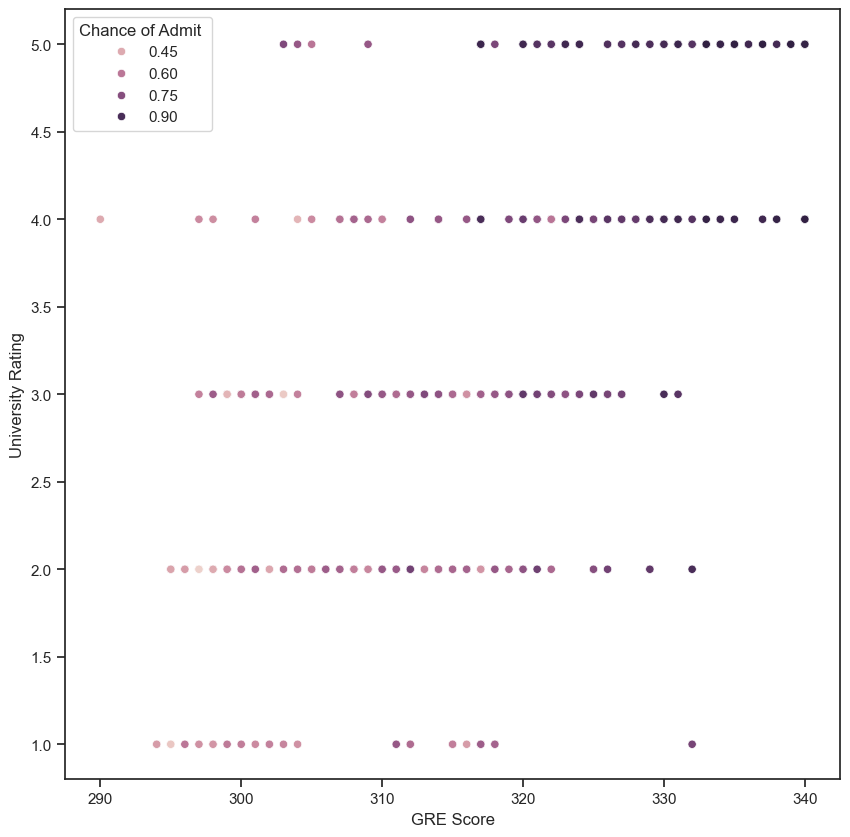

In [76]:
fig, ax = plt.subplots(figsize=(10,10)) 
sns.scatterplot(ax=ax,x='GRE Score', y='University Rating', data=data, hue='Chance of Admit ')

## Ответы на вопросы

### Способы обработки пропусков

Для количественного признакf была исользована методика импутации данных - "внедрения значений".

Процесс импутации - это замещение ошибочных, противоречивых и отсутствующих ответов в процессе редактирования данных другими ответами - значениями показателей. Стратегия проведения импутации определяется заранее при подготовке методологии проведения статистического наблюдения.

Для количественного признака (GRE) использована стратегия медианы (strategy='median').

Причины выбора:

1. Медиана устойчива к выбросам
2. Сохраняет распределение признака
3. Не искажает статистические свойства данных

Для категориального признака (flower_color) использован метод замены пустых значений рейтингом моды. Как видим, мода для цвета растений оказалась "red".

Причины выбора:

1. Простота реализации

### Признаки для построения моделей

Выбранные признаки (features):

- GRE Score - количественный;

- TOEFL Score - количественный;

- University Rating	 - порядковый;

- SOP - порядковый;

Целевой признак:

- Chance of Admit - количественный, приведенный к норм. виду.


Все оригинальные признаки из датасета Graduate Admission 2:

Эти признаки исторически показывают хорошую разделимость классов:

1. Содержат информацию о размерах цветка, что напрямую связано с видом ириса

2. Имеют высокую корреляцию с целевой переменной

Искусственный категориальный признак (flower_color) добавлен для демонстрации работы с разными типами данных, его использование в моделях нельзя назвать целесообразным.

Исключены:

1. Необработанные категориальные признаки (требуют кодирования)

2. Признаки с низкой вариативностью

3. Признаки с высокой корреляцией между собой

## Выводы

После проведения замены пустых значений модель может быть построена.